# Online Sales Coupon Analysis

This project analyzes real-world sales data to understand **how customers use discount coupons** across different **demographics, campaigns, and product types**.

We'll use **Python** for data cleaning, merging, and visualization — focusing on insights instead of machine learning. The final goal is to prepare a **dashboard-ready dataset** for tools like Power BI.

---

## 🎯 Objectives

- Analyze coupon usage by customer demographics  
- Identify trends across campaigns, products, and brands  
- Summarize discount behavior for business insights  
- Prepare clean data for visualization tools

---

**Dataset Source**: Kaggle — *Predicting Coupon Redemption*

📁 Files used:  
- `customer_transaction_data.csv`  
- `customer_demographics.csv`  
- `coupon_item_mapping.csv`  
- `campaign_data.csv`


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trans=pd.read_csv("customer_transaction_data.csv")
camp=pd.read_csv("campaign_data.csv")
customer=pd.read_csv("customer_demographics.csv")
coupon=pd.read_csv("coupon_item_mapping.csv")

In [3]:
# Perform EDA to get better understanding from this data set 
customer.shape  # so customer data have 760 rows and 7 column
camp.shape  # 28 rows and 4 column
trans.shape # 1324566 rows and 7 column
coupon.shape # 92663 rows and 2 column 
# Checking null values-------------------
coupon.isnull().values.any() # no null value 
customer.isnull().values.any() # null value
camp.isnull().values.any() # no null value 
trans.isnull().values.any() # no null values 

np.False_

In [4]:
# Cleaning the datasets
customer.isnull().sum() # martial status = 329 null values and no_of_children = 538 null values
customer.dropna(axis=0,inplace = True)  # remove null values here

In [5]:
print("Is there any null values here ?",customer.isnull().values.any())

Is there any null values here ? False


In [6]:
# To get insights we have to merge some columns from this data sets
# we have coupon id and customer so we analyze coupon with customer relation coupon id with customer id
#trans #date', 'customer_id', 'item_id', 'quantity', 'selling_price',
                      #'other_discount', 'coupon_discount'
customer.columns

Index(['customer_id', 'age_range', 'marital_status', 'rented', 'family_size',
       'no_of_children', 'income_bracket'],
      dtype='object')

In [7]:
# now we do merging here to get more insights from table
df=trans.merge(customer,on='customer_id',how='left')
df.columns # now we create new data set which include info from trans data left side and remaing data of customer right side

Index(['date', 'customer_id', 'item_id', 'quantity', 'selling_price',
       'other_discount', 'coupon_discount', 'age_range', 'marital_status',
       'rented', 'family_size', 'no_of_children', 'income_bracket'],
      dtype='object')

In [8]:
df.isnull().values.any() # remove null values in new table
df.dropna(axis=0,inplace=True)
df.isnull().values.any()

np.False_

In [9]:
# create multiple merge on new df. -------------

In [10]:
coupon.columns

Index(['coupon_id', 'item_id'], dtype='object')

In [11]:
df=df.merge(coupon,on='item_id',how = 'left') # this is the second merge to create relation with coupon with customers
df.columns

Index(['date', 'customer_id', 'item_id', 'quantity', 'selling_price',
       'other_discount', 'coupon_discount', 'age_range', 'marital_status',
       'rented', 'family_size', 'no_of_children', 'income_bracket',
       'coupon_id'],
      dtype='object')

### Data enrichment -- create new usefull columns for the existing one

In [12]:
# Age Grouping
def age_bucket(age):
    if age.startswith('18') or age.startswith('26'):
        return 'Youth'
    elif age.startswith('36') or age.startswith('46'):
        return 'Adult'
    else:
        return 'Senior'
df['age_group'] = df['age_range'].apply(age_bucket) # create a new coloumns 

In [13]:
df.columns

Index(['date', 'customer_id', 'item_id', 'quantity', 'selling_price',
       'other_discount', 'coupon_discount', 'age_range', 'marital_status',
       'rented', 'family_size', 'no_of_children', 'income_bracket',
       'coupon_id', 'age_group'],
      dtype='object')

In [14]:
# martial staus coloumn 
df['marital_status'].unique() # so here is the value like   Married and Single

array(['Married', 'Single'], dtype=object)

In [15]:
def couple_status(status):
   if status=='Married':
       return 1
   else:
       return 0
df['clean_status'] = df['marital_status'].apply(couple_status)

In [16]:
df.columns # here we see some columns which are usefull --> rented,family_size,income_bracket

Index(['date', 'customer_id', 'item_id', 'quantity', 'selling_price',
       'other_discount', 'coupon_discount', 'age_range', 'marital_status',
       'rented', 'family_size', 'no_of_children', 'income_bracket',
       'coupon_id', 'age_group', 'clean_status'],
      dtype='object')

In [17]:
#rented new columns
df['rented']
def new_rented(x):
    if x==1:
        return 'Rented'
    else:
        return 'Own_home'
df['Rented_scene']=df['rented'].apply(new_rented)

In [19]:
#family_size
df['family_size']=pd.to_numeric(df['family_size'],errors='coerce')
def family_scene(s):
    if s<=2:
        return 'small'
    elif s<=5:
        return 'mid_range'
    else:
        return 'large'
df['family_desc']=df['family_size'].apply(family_scene)

In [22]:
df['income_bracket']=pd.to_numeric(df['income_bracket'],errors='coerce')
def income_dist(y):
    if y<=4:
        return 'Low'
    elif y<=5:
        return 'Avg'
    else:
        return 'High'
df['income_scene']=df['income_bracket'].apply(income_dist) 

## Analysis by charts--->

In [30]:
df.columns

Index(['date', 'customer_id', 'item_id', 'quantity', 'selling_price',
       'other_discount', 'coupon_discount', 'age_range', 'marital_status',
       'rented', 'family_size', 'no_of_children', 'income_bracket',
       'coupon_id', 'age_group', 'clean_status', 'Rented_scene', 'family_desc',
       'income_scene'],
      dtype='object')

Text(0, 0.5, 'Count')

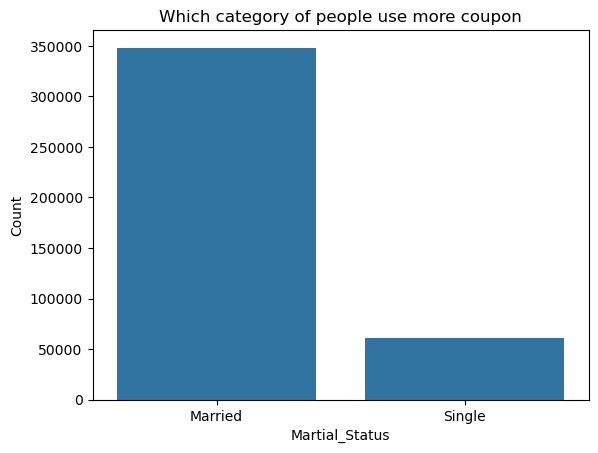

In [33]:
sns.countplot(x='marital_status',data=df)
plt.title("Which category of people use more coupon")
plt.xlabel('Martial_Status')
plt.ylabel('Count')

Text(0.5, 1.0, 'Coupon discount on the basis of age-group')

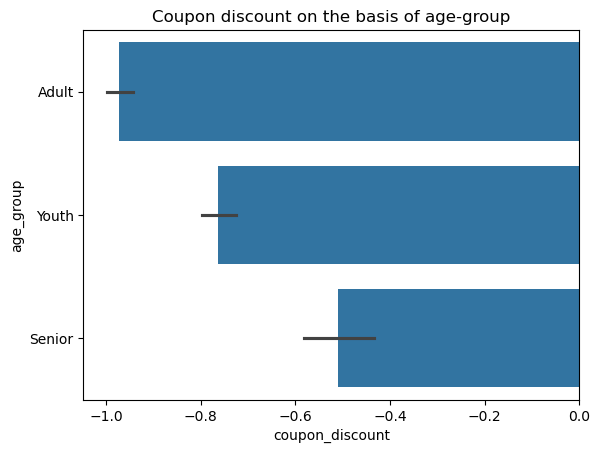

In [39]:
sns.barplot(y='age_group',x='coupon_discount',data=df, estimator = 'mean')
plt.title('Coupon discount on the basis of age-group')

Text(0.5, 1.0, 'Coupon discount per family size')

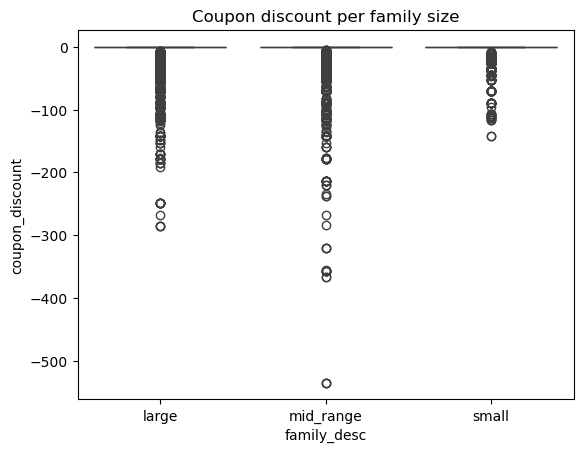

In [44]:
sns.boxplot(x='family_desc',y='coupon_discount',data=df)
plt.title("Coupon discount per family size") 

Text(0.5, 1.0, 'Correlation Heatmap')

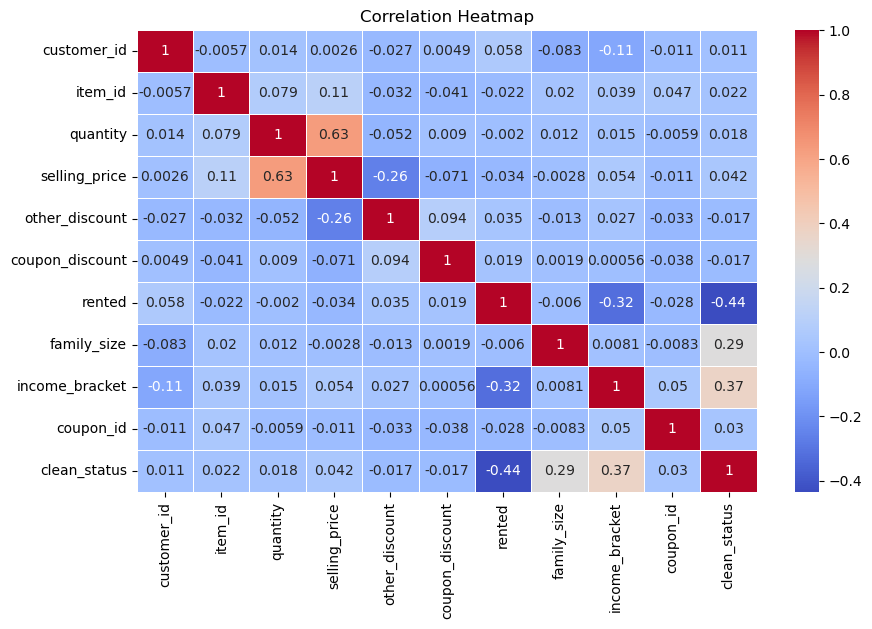

In [48]:
plt.figure(figsize=(10,6)) # for corelation matrix or creating heatmap whole df is present in numeric data type therefore we do some changes
numeric_df=df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")

In [49]:
# save file for powerbi dashbord =>
df.to_csv("cleaned_coupon_analysis_data.csv",index=False)

# Conclusion

###  Key Insights from Online Coupon Sales Analysis

1. **Married people are more likely to redeem coupons.**  
   From the bar charts, married users showed higher coupon usage compared to singles.

2. **Higher income groups redeemed fewer coupons.**  
   People with lower income levels showed more interest in using coupons.

3. **Family size impacts coupon usage.**  
   Users with medium family size (3–4 members) redeemed the most coupons.

4. **Coupon type influences redemption rate.**  
   Certain types of coupons had significantly higher redemption rates.

5. **Age distribution shows younger users are more active.**  
   Most coupon redemptions were done by users between 25–40 years of age.